Use something like the code below to convert your CT image to density using a CT phantom. The CT phantom must be acquired in the same scanner and with the same settings as the CT image that you want to convert.

The CT phantom should have the true density of each capsule written on it or documented somewhere.

I used itk-snap to draw the labels for each capsule in the phantom CT image.

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
density_data = [
#   (name,              rho [g/cc],    label index),
	# ('bone 200 mg/cc',  1.16,   1),
	('adipose',         0.96,   2),
	# ('muscle',          1.06,   3),
	# ('bone 800 mg/cc',  1.53,   4),
	('lung inhale',     0.205,  5),
	('breast 50/50',    0.99,   6),
	('air',             0.0012, 16),
	('muscle',          1.06,   8),
	('bone 200 mg/cc',  1.16,   9),
	('bone 800 mg/cc',  1.53,   10),
	('bone 1000 mg/cc', 1.66,   11),
	('bone 1250 mg/cc', 1.82,   12),
	('bone 1500 mg/cc', 1.99,   13),
	('bone 1750 mg/cc', 2.15,   14),
	('lung exhale',     0.507,  15)
]

density_data = list(sorted(density_data, key=lambda x: x[1]))
ct_phantom = nib.load('../data/CT_density_phantom.nii').get_fdata()
ct_phantom_label = nib.load('../data/CT_density_phantom_labels.nii.gz').get_fdata()

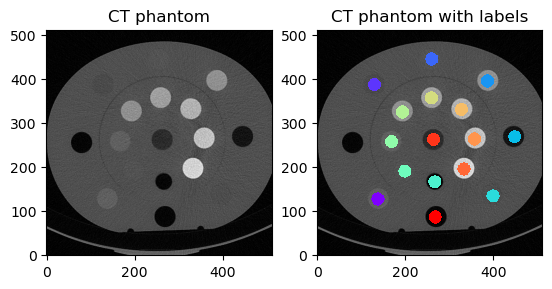

In [3]:
plt.subplot(1, 2, 1)
plt.title("CT phantom")
plt.imshow(ct_phantom[..., 70].T, cmap="gray", origin="lower")

plt.subplot(1, 2, 2)
plt.title("CT phantom with labels")
masked_labels = np.ma.masked_where(ct_phantom_label < 0.5, ct_phantom_label)
plt.imshow(ct_phantom[..., 70].T, cmap="gray", origin="lower")
plt.imshow(masked_labels[..., 70].T, interpolation='nearest', cmap="rainbow", origin='lower')
plt.show()

In [4]:
ct_values = []
rho_values = []
for name, rho, label_index in density_data:
    ct_values.append(np.mean(ct_phantom[ct_phantom_label == label_index]))
    rho_values.append(rho)

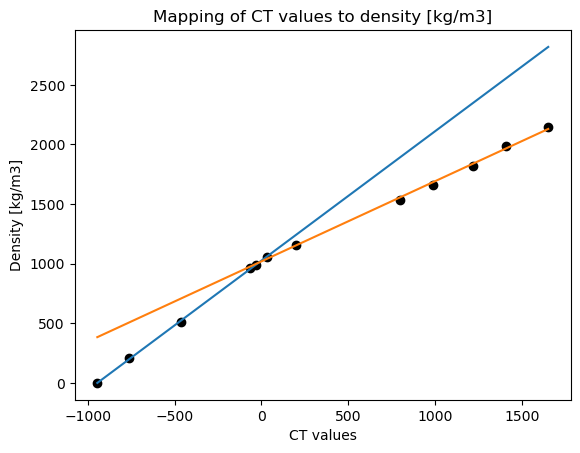

In [5]:
rho_values = [x*1000 for x in rho_values] # convert g/cm3 to kg/m3

plt.scatter(ct_values, rho_values, color='black')

split = 5 # this will depend on your phantom and what capsules you have in it

slope1, intercept1 = np.polyfit(ct_values[:split], rho_values[:split], deg=1)
plt.plot([ct_values[0], ct_values[-1]], [ct_values[0]*slope1+intercept1, ct_values[-1]*slope1+intercept1])

slope2, intercept2 = np.polyfit(ct_values[split:], rho_values[split:], deg=1)
plt.plot([ct_values[0], ct_values[-1]], [ct_values[0]*slope2+intercept2, ct_values[-1]*slope2+intercept2])

plt.xlabel('CT values')
plt.ylabel('Density [kg/m3]')
plt.title('Mapping of CT values to density [kg/m3]')
plt.show()

In [6]:
def ct_to_density(ct, slopes, intercepts):
    return np.min([ct*s+i for s,i in zip(slopes, intercepts)], axis=0)

In [7]:
ct_image = nib.load('../data/me/ct.nii')
ct_data = ct_image.get_fdata()
density_data = ct_to_density(ct_data, [slope1, slope2], [intercept1, intercept2])
density_image = nib.Nifti1Pair(density_data, ct_image.affine)
nib.save(density_image, "../data/me/true_density_from_ct.nii.gz")

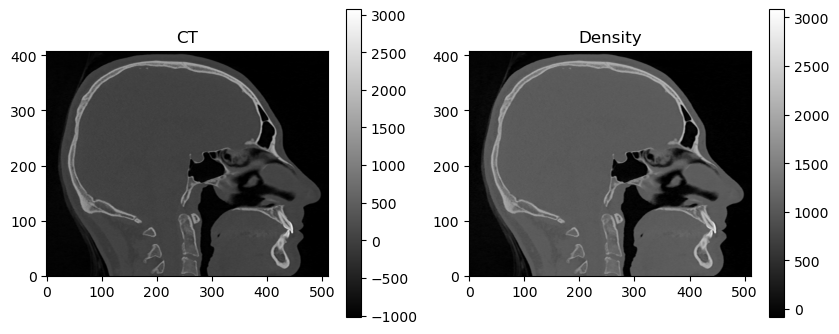

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("CT")
plt.imshow(ct_data[250, ...].T, cmap="gray", origin="lower")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Density")
plt.imshow(density_data[250, ...].T, cmap="gray", origin="lower")
plt.colorbar()

plt.show()

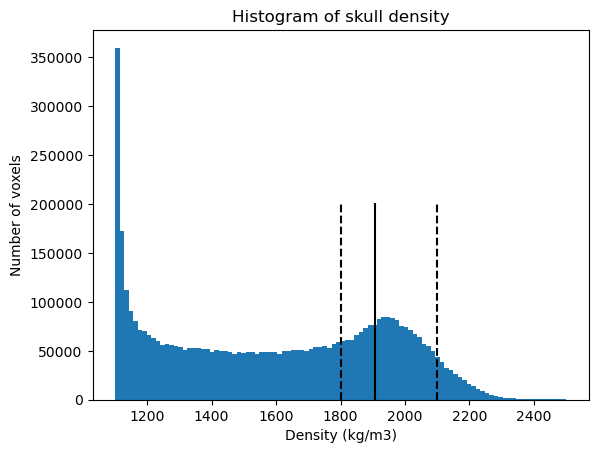

In [9]:
# lower threshold is to exclude soft-tissue values
# upper threshold is to exclude very dense things like the teeth or the jaw
thresholded_density_values = density_data[(1100 < density_data) & (density_data < 2500)].flatten()

plt.hist(thresholded_density_values, bins=100)

# The average/minimum/maximum density of cortical bone is from:
# https://itis.swiss/virtual-population/tissue-properties/database/density
plt.plot([1800, 1800], [0, 200000], '--k')
plt.plot([1908, 1908], [0, 200000], '-k')
plt.plot([2100, 2100], [0, 200000], '--k')

plt.title('Histogram of skull density')
plt.xlabel('Density (kg/m3)')
plt.ylabel('Number of voxels')
plt.show()

The cortical bone peak is probably a bit too high here because the image includes the teeth and the jaw which are very dense.